# Kinase fusion analysis

Here, we take the fusion genes that include kinases and analyze them to understand what new domain combinations are being created with the kinase domain and if there are biases for either the pTyr or pSer/Thr systems.

In [1]:
import dansy
import colorsys
import pandas as pd
import numpy as np
import scipy.stats as stats
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
from collections import Counter

In [2]:
# Now let's set up a handful of matplotlib default values
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['lines.markeredgewidth'] = 0.01
plt.rcParams['figure.dpi'] = 300

In [3]:
# We have the dansy results from tcga and ccle already so let's import them
tcga_dansy_res = pd.read_csv('260324_Individual_Fusion_Summary_info.csv', index_col = 0)
ccle_dansy_res = pd.read_csv('260324_CCLE_dansy_fusion.csv', index_col=0)

for x in ['domain_architecture', 'dansy_impact','h_contribution','t_contribution']:
    tcga_dansy_res[x].fillna('', inplace=True)
    ccle_dansy_res[x].fillna('', inplace=True)

In [4]:
# Now let's limit the analysis to individual fusion proteins and not the breakpoints
tcga_dansy_res = tcga_dansy_res.filter(['name','PatientID','dansy_impact', 'domain_architecture','h_uniprot','t_uniprot','h_contribution','t_contribution','id']).drop_duplicates(subset = ['name', 'PatientID', 'dansy_impact', 'domain_architecture'])
ccle_dansy_res = ccle_dansy_res.filter(['fusion_protein','ModelID','dansy_impact', 'domain_architecture','h_uniprot','t_uniprot','h_contribution','t_contribution','id']).drop_duplicates(subset = ['fusion_protein', 'ModelID', 'dansy_impact', 'domain_architecture'])

In [5]:
# Now getting the ptyr and pser/thr kinases
tyr_sys = pd.read_csv('data/Current_Multispecies_Files/H_sapiensFull_pTyr_System_Reference_File_2026_0820.csv')
serthr_sys = pd.read_csv('data/Current_Multispecies_Files/H_sapiensFull_pSerThr_System_Reference_File_2026_0820.csv')

# Kinases only
tyr_kins = tyr_sys[tyr_sys['Interpro Domains'].apply(lambda x: 'IPR000719' in x)]
tyr_kins = dansy.ngramUtilities.add_Interpro_ID_architecture(tyr_kins)
serthr_kins = serthr_sys[serthr_sys['Interpro Domains'].apply(lambda x: 'IPR000719' in x)]
serthr_kins = dansy.ngramUtilities.add_Interpro_ID_architecture(serthr_kins)
# For the kinases that are dual specificity keeping them only in the tyr kinase cases for the time being
serthr_kins = serthr_kins[~serthr_kins['UniProt ID'].isin(tyr_kins['UniProt ID'])]
all_kins = set(tyr_kins['UniProt ID']).union(serthr_kins['UniProt ID'])

In [6]:
# Let's get the natural n-grams so we can highlight the novel ones within the network.
ref_df = dansy.import_proteome_files(ref_file_dir='./data/Current_Human_Proteome',
                                     ref_file_suffix='2026_0715.csv')
kinase_net = dansy.dansy(protsOI = list(set(serthr_kins['UniProt ID']).union(tyr_kins['UniProt ID'])), ref = ref_df, n = 15, collapse = False)

Starting to fetch n-grams.
Finished getting all n-grams
Finished creating edgelist


In [7]:
tcga_dansy_res['tk'] = tcga_dansy_res[['h_uniprot','t_uniprot']].isin(tyr_kins['UniProt ID'].values).any(axis = 1)
tcga_dansy_res['stk'] = tcga_dansy_res[['h_uniprot','t_uniprot']].isin(serthr_kins['UniProt ID'].values).any(axis = 1)
tcga_dansy_res['novel'] = tcga_dansy_res.dansy_impact.apply(lambda x: "Novel" in x)
tcga_dansy_res['retain'] = tcga_dansy_res.domain_architecture.apply(lambda x: "IPR000719" in x) 
ccle_dansy_res['tk'] = ccle_dansy_res[['h_uniprot','t_uniprot']].isin(tyr_kins['UniProt ID'].values).any(axis = 1)
ccle_dansy_res['stk'] = ccle_dansy_res[['h_uniprot','t_uniprot']].isin(serthr_kins['UniProt ID'].values).any(axis = 1)
ccle_dansy_res['novel'] = ccle_dansy_res.dansy_impact.apply(lambda x: "Novel" in x)
ccle_dansy_res['retain'] = ccle_dansy_res.domain_architecture.apply(lambda x: "IPR000719" in x) 

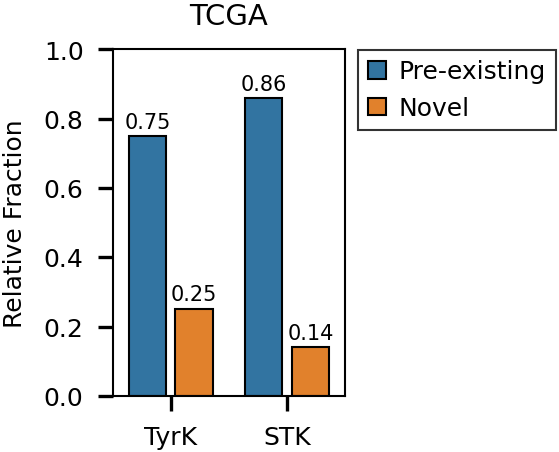

In [8]:
x1 = pd.crosstab(tcga_dansy_res.tk,tcga_dansy_res.novel, normalize='index').loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(tcga_dansy_res.stk,tcga_dansy_res.novel, normalize='index').loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'STK'})
tcga_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'novel').dropna()
ax = sns.barplot(tcga_kin_sum, 
                 x = 'variable',
                 y = 'value', 
                 hue = 'novel',
                 gap=0.2,
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Relative Fraction',fontdict={'fontsize':6})
plt.title('TCGA',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.ylim(0,1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1, fontsize=5)
plt.savefig('Figures/Manuscript/Figure_4/4B_Relative_Fraction_Novel_Kinase_fusions.svg')

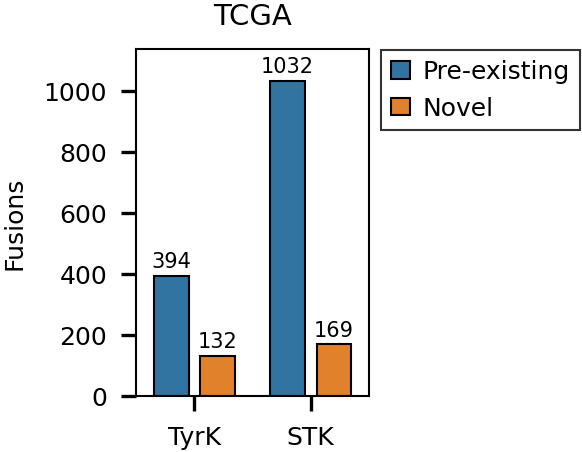

In [9]:
x1 = pd.crosstab(tcga_dansy_res.tk,tcga_dansy_res.novel).loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(tcga_dansy_res.stk,tcga_dansy_res.novel).loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'STK'})
tcga_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'novel').dropna()
ax = sns.barplot(tcga_kin_sum, 
                 x = 'variable', 
                 y = 'value', 
                 hue = 'novel',
                 gap = 0.25,
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)
plt.xlabel(None)
plt.ylabel('Fusions',fontdict={'fontsize':6})
plt.title('TCGA',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.margins(y=.1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=1, fontsize=5)
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15A_TCGA_Count_Novel_Kinase_fusions.svg')

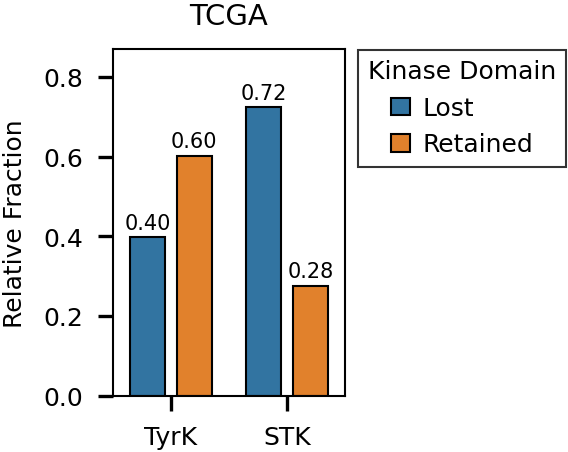

In [10]:
x1 = pd.crosstab(tcga_dansy_res.tk,tcga_dansy_res.retain, normalize='index').loc[True].rename(index={False:'Lost',True:'Retained'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(tcga_dansy_res.stk,tcga_dansy_res.retain, normalize='index').loc[True].rename(index={False:'Lost',True:'Retained'}).reset_index().rename(columns={True:'STK'})
tcga_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'retain').dropna()
ax = sns.barplot(tcga_kin_sum, 
                 x = 'variable', 
                 y = 'value', 
                 hue = 'retain',
                 gap = 0.25,
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title='Kinase Domain', fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,title_fontsize=6,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Relative Fraction',fontdict={'fontsize':6})
plt.title('TCGA',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.margins(y=0.2)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1, fontsize=5)
plt.savefig('Figures/Manuscript/Figure_4/4C_Retained_Kinase_domain_fusions.svg')

In [11]:
# Relative fraction of kinase domains retained across all kinase fusions
tcga_dansy_res[tcga_dansy_res.tk | tcga_dansy_res.stk].retain.sum()/len(tcga_dansy_res[tcga_dansy_res.tk | tcga_dansy_res.stk])

0.37383177570093457

In [12]:
# Number of kinase fusions
len(tcga_dansy_res[tcga_dansy_res.tk | tcga_dansy_res.stk])

1712

Repeating with the CCLE

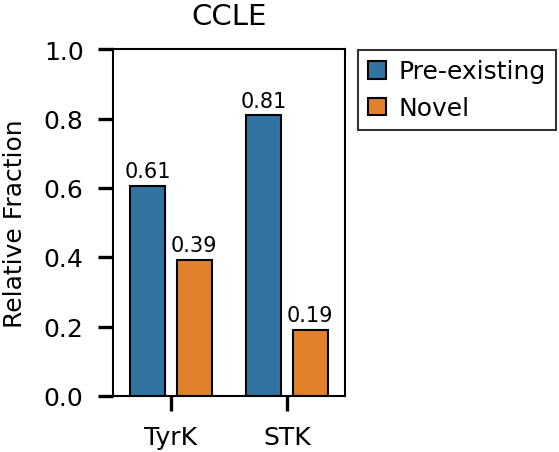

In [13]:
x1 = pd.crosstab(ccle_dansy_res.tk,ccle_dansy_res.novel, normalize='index').loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(ccle_dansy_res.stk,ccle_dansy_res.novel, normalize='index').loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'STK'})
ccle_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'novel').dropna()
ax = sns.barplot(ccle_kin_sum, 
                 x = 'variable', 
                 y = 'value', 
                 hue = 'novel',
                 gap=0.25,
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Relative Fraction',fontdict={'fontsize':6})
plt.title('CCLE',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.ylim(0,1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1, fontsize=5)
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15A_Retained_Kinase_domain_fusions.svg')

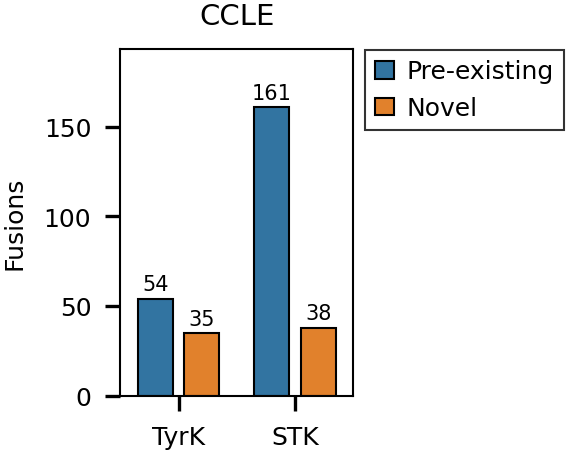

In [14]:
x1 = pd.crosstab(ccle_dansy_res.tk,ccle_dansy_res.novel).loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(ccle_dansy_res.stk,ccle_dansy_res.novel).loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'STK'})
ccle_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'novel').dropna()
ax = sns.barplot(ccle_kin_sum, 
                 x = 'variable', 
                 y = 'value', 
                 hue = 'novel',
                 gap = 0.25,
                 edgecolor = 'k', linewidth = 0.5)
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Fusions',fontdict={'fontsize':6})
plt.title('CCLE',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.margins(y=0.2)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=1, fontsize=5)
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15B_Count_Kinase_domain_fusions.svg')

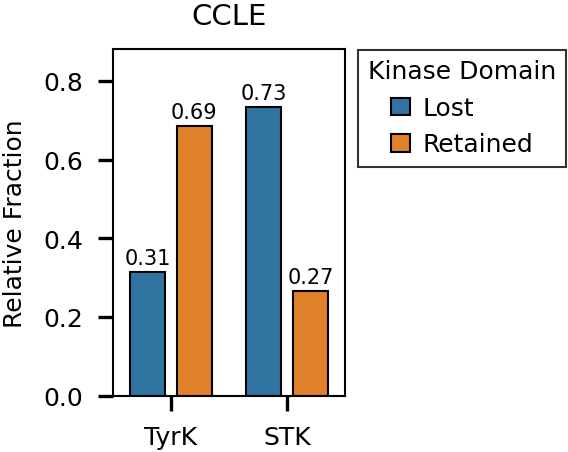

In [15]:
x1 = pd.crosstab(ccle_dansy_res.tk,ccle_dansy_res.retain, normalize='index').loc[True].rename(index={False:'Lost',True:'Retained'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(ccle_dansy_res.stk,ccle_dansy_res.retain, normalize='index').loc[True].rename(index={False:'Lost',True:'Retained'}).reset_index().rename(columns={True:'STK'})
kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'retain').dropna()
ax = sns.barplot(kin_sum, 
                 x = 'variable', 
                 y = 'value', 
                 hue = 'retain',
                 gap = 0.25,
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title='Kinase Domain', fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,title_fontsize=6,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Relative Fraction',fontdict={'fontsize':6})
plt.title('CCLE',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.margins(y=0.2)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1, fontsize=5)
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15C_Retained_Kinase_domain_fusions.svg')

# Building a DANSy n-gram network to evaluate kinase fusions

An unfortunate aspect of the base dansy class is that it is currently built to take in a reference file generated by CoDIAC, but we can get around that by using specific pieces of it.

In [18]:
tcga_kins_only = tcga_dansy_res[(tcga_dansy_res.tk | tcga_dansy_res.stk) & (tcga_dansy_res.retain)].copy()
tcga_kin_all_ngrams = dansy.ngramUtilities.return_ngrams_from_list(tcga_kins_only.domain_architecture,21)

tcga_ngram_id_dict = {}
for ngram in tcga_kin_all_ngrams:
    ids = tcga_kins_only[tcga_kins_only.domain_architecture.apply(lambda x: ngram in x)]['id'].values
    tcga_ngram_id_dict[ngram] = ids

tcga_kin_ngrams,tcga_kin_collapsed_ngrams = dansy.ngramUtilities.concatenate_ngrams(tcga_ngram_id_dict) 
tcga_kin_edgelist = dansy.ngramUtilities.create_ngram_edgelist(tcga_kin_ngrams)



In [19]:
tcga_prots_net = dansy.dansy(protsOI=list(set(tcga_kins_only.h_uniprot).union(tcga_kins_only.t_uniprot)), ref = ref_df, n = 21, collapse = False)

Starting to fetch n-grams.
Finished getting all n-grams
Finished creating edgelist


In [20]:
G = nx.from_pandas_edgelist(tcga_kin_edgelist)
G.remove_edges_from(nx.selfloop_edges(G))

In [21]:
pos = nx.nx_agraph.graphviz_layout(G,prog='sfdp')


In [22]:
# Let's make a dictionary to help identify if the domain n-gram is associated with the TKs and/or STKs
ngram_kintype = {}
for ngram, ids in tcga_ngram_id_dict.items():
    infoOI = tcga_kins_only[tcga_kins_only.id.isin(ids)]
    tk_check = infoOI.tk.any()
    stk_check = infoOI.stk.any()
    if tk_check and stk_check:
        kin_type = 'Both'
    elif stk_check:
        kin_type = 'STK'
    elif tk_check:
        kin_type = 'TyrK'
    else:
        raise ValueError('Something went wrong')
    
    ngram_kintype[ngram] = kin_type

# Now create a color mapper
col_map = {'TyrK':'firebrick','STK':'deepskyblue', 'Both':'darkviolet'}

In [23]:
f, axs = plt.subplots(1,2,dpi=300, figsize = (3.5,3))
plt.close()

In [24]:
node_size = []
node_color = []
# Scaling to make sure they aren't too big
for node in G.nodes:
    if node == 'IPR000719':
        node_size.append(30)
    else:
        node_size.append(5)
    node_color.append(col_map[ngram_kintype[node]])

nx.draw(G, pos = pos, node_size = node_size, linewidths = 0.25, width = 0.25,edgecolors='k', node_color=node_color, ax=axs[0])
axs[0].set_title('All Kinase Fusion n-grams', fontdict = {'fontsize':7}, pad = 0)
#plt.savefig('Figures/Manuscript/Figure_4/4C_Kinase_domain_ngram_network.svg')

Text(0.5, 1.0, 'All Kinase Fusion n-grams')

In [25]:
# Now taking the above information and then emphasizing those that are novel domain combinations
new_ngrams = [n for n in G.nodes if n not in tcga_prots_net.ngrams]
new_node_size = []
new_node_color = []
for node in G.subgraph(new_ngrams+['IPR000719']):
    new_node_color.append(col_map[ngram_kintype[node]])
    if node == 'IPR000719':
        new_node_size.append(30)
    else:
        new_node_size.append(5)
nx.draw(G.subgraph(new_ngrams+['IPR000719']), pos, node_size =new_node_size, node_color=new_node_color ,linewidths = 0.25,edgecolors='k',width = 0.25,ax = axs[1])
axs[1].set_title('Novel Domain n-grams', fontdict = {'fontsize':7}, pad = 0)
#plt.savefig('Figures/Manuscript/Figure_4/4Cii_Kinase_domain_novel_ngram_network.svg')

Text(0.5, 1.0, 'Novel Domain n-grams')

In [26]:
for ax in axs:
    ax.set_aspect(1.4)
h = [Line2D([],[],marker='o', color='w', markerfacecolor=col_map[k], markeredgewidth=0.25, markeredgecolor='k',label = k) for k in col_map.keys()]
axs[0].legend(handles = h, handletextpad= 0, ncols = 3, fancybox= False, edgecolor = 'k', bbox_to_anchor = [0.5,-0.15], loc = 'lower left', fontsize= 6).get_frame().set_linewidth(0.5)
f.savefig('Figures/Manuscript/Figure_4/4C_Kinase_ngram_networks.svg')

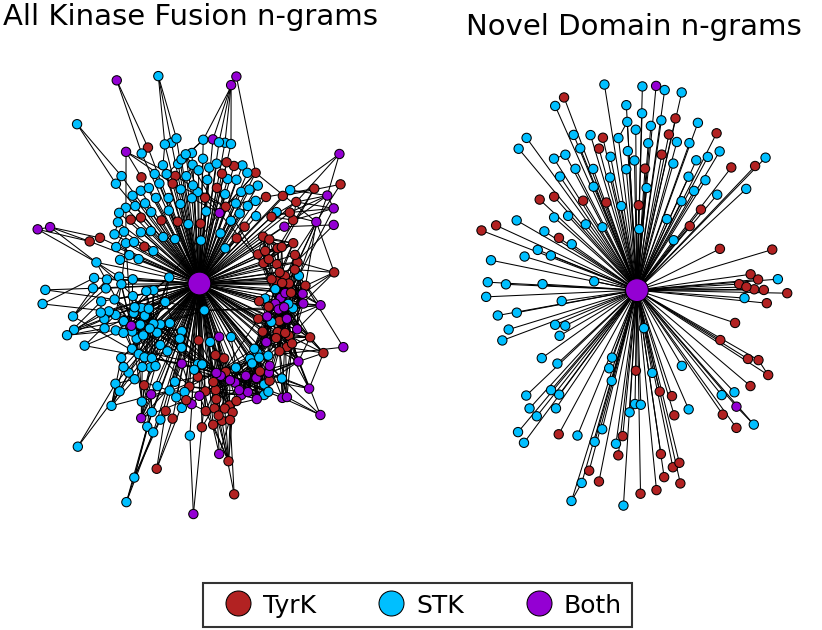

In [27]:
f

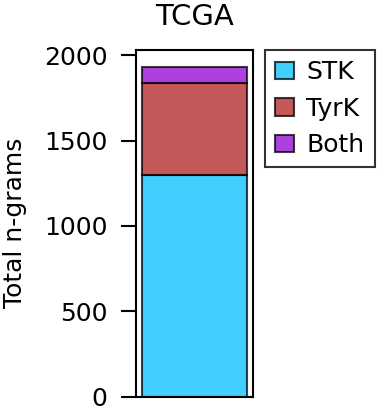

In [28]:
x = pd.Series(ngram_kintype).value_counts()

f, ax = plt.subplots(figsize = (0.5,1.5), dpi = 300)
bottom = 0
for lab,i in x.items():
    ax.bar(0, i,0.5,label=lab, bottom = bottom,
           color = col_map[lab],
           alpha = 0.75,
           linewidth = 0.5, edgecolor = 'k')
    bottom += i
ax.legend(bbox_to_anchor = [1,1.035],
          fancybox = False,
          edgecolor = 'k',
          handlelength = 0.75, handletextpad = 0.5,
          fontsize=6).get_frame().set_linewidth(0.5)
ax.tick_params(labelbottom = False, bottom=False, labelsize = 6,width = 0.5)

# For the next plot
handles,labels = ax.get_legend_handles_labels()
plt.title('TCGA', fontdict={'fontsize':7})
plt.ylabel('Total n-grams')
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15E_ngram_dist.svg')

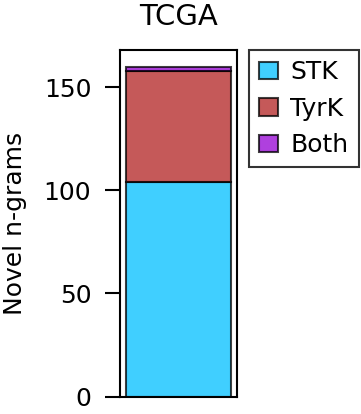

In [29]:
newngram_kintype = {k:v for k,v in ngram_kintype.items() if k in new_ngrams}
x = pd.Series(newngram_kintype).value_counts()
f, ax = plt.subplots(figsize = (0.5,1.5), dpi = 300)
bottom = 0
for lab,i in x.items():
    ax.bar(0, i,0.5,label=lab, bottom = bottom,color = col_map[lab],
           alpha=0.75,
           linewidth = 0.5, edgecolor = 'k')
    bottom += i
ax.legend(bbox_to_anchor = [1,1.035],
          fancybox = False,
          edgecolor = 'k',
          handlelength = 0.75, handletextpad = 0.5,
          fontsize=6).get_frame().set_linewidth(0.5)
ax.tick_params(labelbottom = False, bottom=False, labelsize = 6,width = 0.5)

# For the next plot
handles,labels = ax.get_legend_handles_labels()
plt.title('TCGA', fontdict={'fontsize':7})
plt.ylabel('Novel n-grams')
plt.savefig('Figures/Manuscript/Figure_4/TCGA_Novel_ngram_distribution.svg')

In [30]:
# Now getting the domain n-gram counts for the top 10ish n-grams
ngram_counts = pd.Series(index = [k for k in tcga_ngram_id_dict.keys()], data = [len(v) for v in tcga_ngram_id_dict.values()]).sort_values(ascending=False)


In [31]:
ngram_count_bk = {}
for ngram,v in tcga_ngram_id_dict.items():
    infoOI = tcga_kins_only[tcga_kins_only.id.isin(v)]
    tk_count = infoOI.tk.sum()
    stk_count = infoOI.stk.sum()
    dual_count = (infoOI.tk & infoOI.stk).sum()

    if dual_count % 2: # If there is an odd number reduce the STK and TyrK counts based on which one has more.
        offset = dual_count//2
        if tk_count > stk_count:
            tk_offset = offset + 1
            stk_offset = offset
        else:
            tk_offset = offset
            stk_offset = offset + 1 
    else:
        tk_offset = stk_offset = dual_count // 2

    ngram_count_bk[ngram] = {
        'Total': tk_count + stk_count - dual_count,
        'TyrK': tk_count - tk_offset,
        'STK': stk_count - stk_offset
    }

In [32]:
ngram_counts

IPR000719                                                                          640
IPR003598                                                                          107
IPR003598|IPR003598                                                                 94
IPR003598|IPR000719                                                                 93
IPR003598|IPR003598|IPR000719                                                       87
                                                                                  ... 
IPR001627|IPR016201|IPR057563                                                        1
IPR001509                                                                            1
IPR001506|IPR000859|IPR000859|IPR000742|IPR000859|IPR000742|IPR000859|IPR000859      1
IPR001506|IPR000859|IPR000859|IPR000742|IPR000859|IPR000742|IPR000859                1
IPR059828                                                                            1
Length: 1934, dtype: int64

In [33]:
count_bk = pd.DataFrame.from_dict(ngram_count_bk,orient='index')
count_bk.reset_index(names='ngram',inplace=True)
count_bk.sort_values('Total', ascending=False, inplace=True)
count_bk_long = count_bk.drop('Total', axis = 1).melt(var_name='Kinase',id_vars = 'ngram')
count_bk_long['legible_ngram'] = count_bk_long.ngram.apply(tcga_prots_net.return_legible_ngram)

In [34]:
count_bk

,ngram,Total,TyrK,STK
223,IPR000719,640,313,327
947,IPR003598,107,94,13
971,IPR003598|IPR003598,94,90,4
948,IPR003598|IPR000719,93,90,3
972,IPR003598|IPR003598|IPR000719,87,86,1
...,...,...,...,...
715,IPR001627|IPR016201|IPR057563,1,0,1
707,IPR001509,1,1,0
706,IPR001506|IPR000859|IPR000859|IPR000742|IPR000...,1,0,1
705,IPR001506|IPR000859|IPR000859|IPR000742|IPR000...,1,0,1


In [ ]:
natural_kincounts = count_bk.copy()
natural_kincounts[['Total', 'TyrK', 'STK']] = np.nan
natural_kincounts.set_index('ngram', inplace=True)
cnt = 0
for ngram in natural_kincounts.index:
    if ngram in kinase_net.all_ngrams:
        ngram_prots = kinase_net.interpro2uniprot[ngram]
        natural_kincounts.loc[ngram,'Total'] = len(ngram_prots)
        natural_kincounts.loc[ngram,'TyrK'] = len(set(ngram_prots).intersection(tyr_kins['UniProt ID']))
        natural_kincounts.loc[ngram,'STK']= len(set(ngram_prots).intersection(serthr_kins['UniProt ID']))
    else:
        cnt += 1

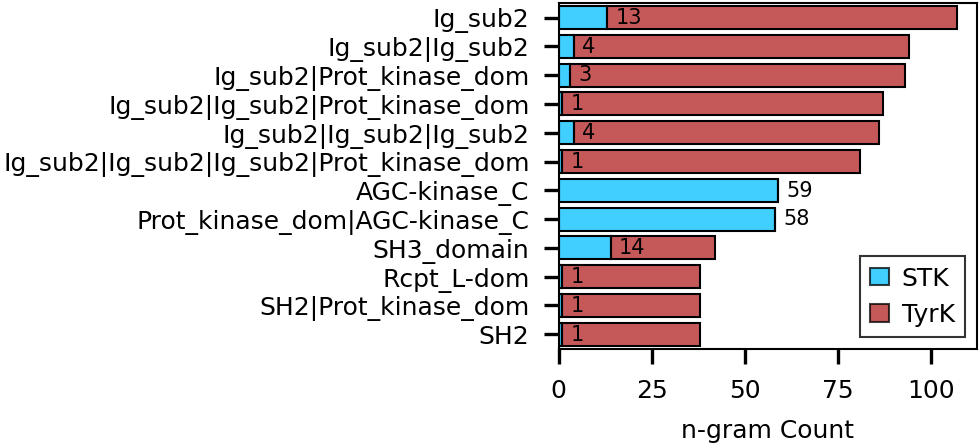

In [66]:
n2show = 12
ngrams2show = ngram_counts.index[1:n2show+1]
ax = sns.histplot(count_bk_long[count_bk_long.ngram.isin(ngrams2show)],
             weights = 'value',
             y='legible_ngram',
             hue='Kinase', 
             palette=col_map,
             edgecolor = 'k', linewidth = 0.5,multiple='stack',shrink=0.8,)

plt.xlabel('n-gram Count', fontdict={'fontsize':6})
plt.ylabel(None)
plt.legend(handles[0:2], labels[0:2],handlelength = 0.75, handletextpad = 0.5,
           fancybox = False, edgecolor = 'k', fontsize = 6).get_frame().set_linewidth(0.5)
plt.margins(y=0.01)
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.8,1.5)

# Annotate only the STK values at the right edge of each STK segment
for patch in ax.containers[0].patches:
    val = patch.get_width()
    if val > 0:
        ax.annotate(
            f'{int(val)}',
            xy=(patch.get_x() + patch.get_width(), patch.get_y() + patch.get_height() / 2),
            xytext=(2, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=5,
            color='k',
            clip_on=False
        )
plt.tick_params(labelsize=6)
plt.savefig('Figures/Manuscript/Figure_4/4D_top_ngram_counts.svg')

In [65]:
natural_kincounts.filter(ngrams2show, axis=0)

,Total,TyrK,STK
IPR003598,23.0,14.0,9.0
IPR003598|IPR003598,16.0,11.0,5.0
IPR003598|IPR000719,11.0,7.0,4.0
IPR003598|IPR003598|IPR000719,9.0,6.0,3.0
IPR003598|IPR003598|IPR003598,13.0,8.0,5.0
IPR003598|IPR003598|IPR003598|IPR000719,7.0,5.0,2.0
IPR000961,55.0,0.0,55.0
IPR000719|IPR000961,55.0,0.0,55.0
IPR001452,29.0,21.0,8.0
IPR000494,7.0,6.0,1.0


To find out if they are exploring the network differently will see what the path length distribution of the novel domains to the kinase domain are like. (This analysis may not be included in the manuscript)

In [60]:
complete_proteome_dansy = dansy.dansy(ref=ref_df, n=10, collapse=True)

Starting to fetch n-grams.
Finished getting all n-grams
Collapsing n-grams
Finished creating edgelist


In [61]:
# Let's limit the kinase fusion information to only those with novel domain architectures
novel_info = tcga_kins_only[(tcga_kins_only.novel) & (tcga_kins_only.retain)]

# Get the contributions that do not contain the kinase domain
def get_kinase_type(row):
    if row['tk'] and row['stk']:
        return 'Both'
    elif row['tk']:
        return 'TyrK'
    else:
        return 'STK'

novel_contribs = novel_info.apply(lambda row: row['h_contribution'] if 'IPR000719' not in row['h_contribution'] else row['t_contribution'], axis = 1).tolist()
final_arch = novel_info.domain_architecture.tolist()

contrib_kinases = {}
for c,ar in zip(novel_contribs, final_arch):
    if c in contrib_kinases:
        if contrib_kinases[c] == newngram_kintype[ar]:
            pass
        else:
            contrib_kinases[c] = 'Both'
    else:
        contrib_kinases[c] = newngram_kintype[ar]

In [62]:
contrib_counts = Counter(novel_contribs)

novel_ngram_dict = {}
for ngram in set(novel_contribs):
    if ngram in complete_proteome_dansy.collapsed_ngrams: # Determine if the n-gram was collapsed
        cands = [n for n in complete_proteome_dansy.ngrams]
    elif len(ngram.split('|')) > 10:
        # Get the candidates from the one that has the ngram
        cands = set(dansy.ngramUtilities.return_ngrams_from_list([ngram]).keys()).intersection(complete_proteome_dansy.ngrams)
    else:
        cands = [ngram]

    try:
        
        x = min([nx.shortest_path_length(complete_proteome_dansy.G, 'IPR000719', cand) for cand in cands])
    except nx.NetworkXNoPath:
        x = np.nan
    novel_ngram_dict[ngram] = {'path_length':x,
                               'count':contrib_counts[ngram],
                               'kinase':contrib_kinases[ngram]}


In [63]:
novel_ngram_info = pd.DataFrame.from_dict(novel_ngram_dict, orient='index')
novel_ngram_info.reset_index(names = 'ngram', inplace=True)
novel_ngram_info['legible_ngram'] = novel_ngram_info.ngram.apply(tcga_prots_net.return_legible_ngram)
novel_ngram_info.fillna(0, inplace=True)
novel_ngram_info.sort_values('count',inplace=True, ascending=False)

In [64]:
novel_ngram_info

,ngram,path_length,count,kinase,legible_ngram
101,IPR003118,0.0,10,TyrK,Pointed_dom
117,IPR007707,0.0,9,TyrK,TACC_C
45,IPR022174,0.0,4,TyrK,NCOA4_N
54,IPR001841|IPR000315|IPR000315|IPR003649,3.0,4,Both,Znf_RING|Znf_B-box|Znf_B-box|Bbox_C
12,IPR035624,0.0,4,STK,AGGF1_OCRE
...,...,...,...,...,...
48,IPR057480,0.0,1,STK,MAP1A/B/S-like_MBL
47,IPR034464|IPR012317,5.0,1,STK,PAR10_RRM1_2|Poly(ADP-ribose)pol_cat_dom
43,IPR007604,0.0,1,STK,CP2
42,IPR000504|IPR000504|IPR000504|IPR000504,3.0,1,STK,RRM_dom|RRM_dom|RRM_dom|RRM_dom


In [97]:
lab

'Both'

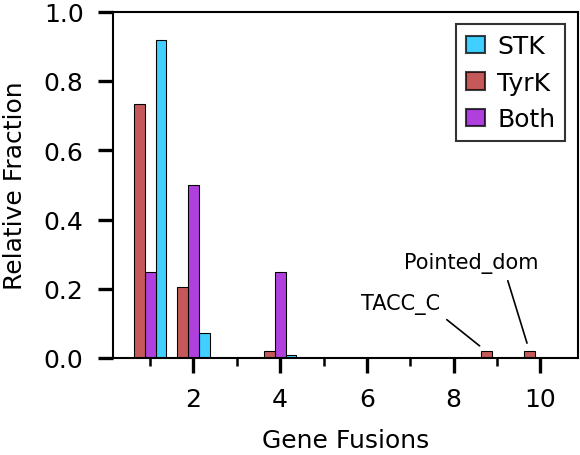

In [114]:
f, ax = plt.subplots(figsize=(2,1.5))
sns.histplot(novel_ngram_info, 
             hue='kinase', 
             x='count', 
             multiple='dodge', 
             discrete=True, 
             shrink=0.75, 
             stat='probability', 
             common_norm=False, 
             edgecolors= 'k',
             linewidths = 0.5,
             ax= ax,
             palette=col_map
             )
ax.legend(handles, labels,handlelength = 0.75, handletextpad = 0.5,
           fancybox = False, edgecolor = 'k', fontsize = 6).get_frame().set_linewidth(0.5)
ax.tick_params(labelsize=6)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.set_ylim(0,1)
ax.set_ylabel('Relative Fraction')
ax.set_xlabel('Gene Fusions')

annots = ['IPR007707','IPR003118']
rects = ax.containers[2]
for rect,lab,xy,relpos in zip(rects[-2:],[complete_proteome_dansy.return_legible_ngram(i) for i in annots],[(-30,10),(-30,20)],[(1,0),(0.75,0)]):

    ax.annotate(
        lab,
        xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
        xytext=xy,
        textcoords='offset points',
        fontsize=5,
        arrowprops={'arrowstyle': '-', 'lw': 0.4, 'color': 'k','relpos':relpos},
        bbox = dict(pad=0, facecolor='w', lw=0)
    )
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/Novel_Kinase_Fusions_Fusion_Count.svg')

<Axes: xlabel='path_length', ylabel='Probability'>

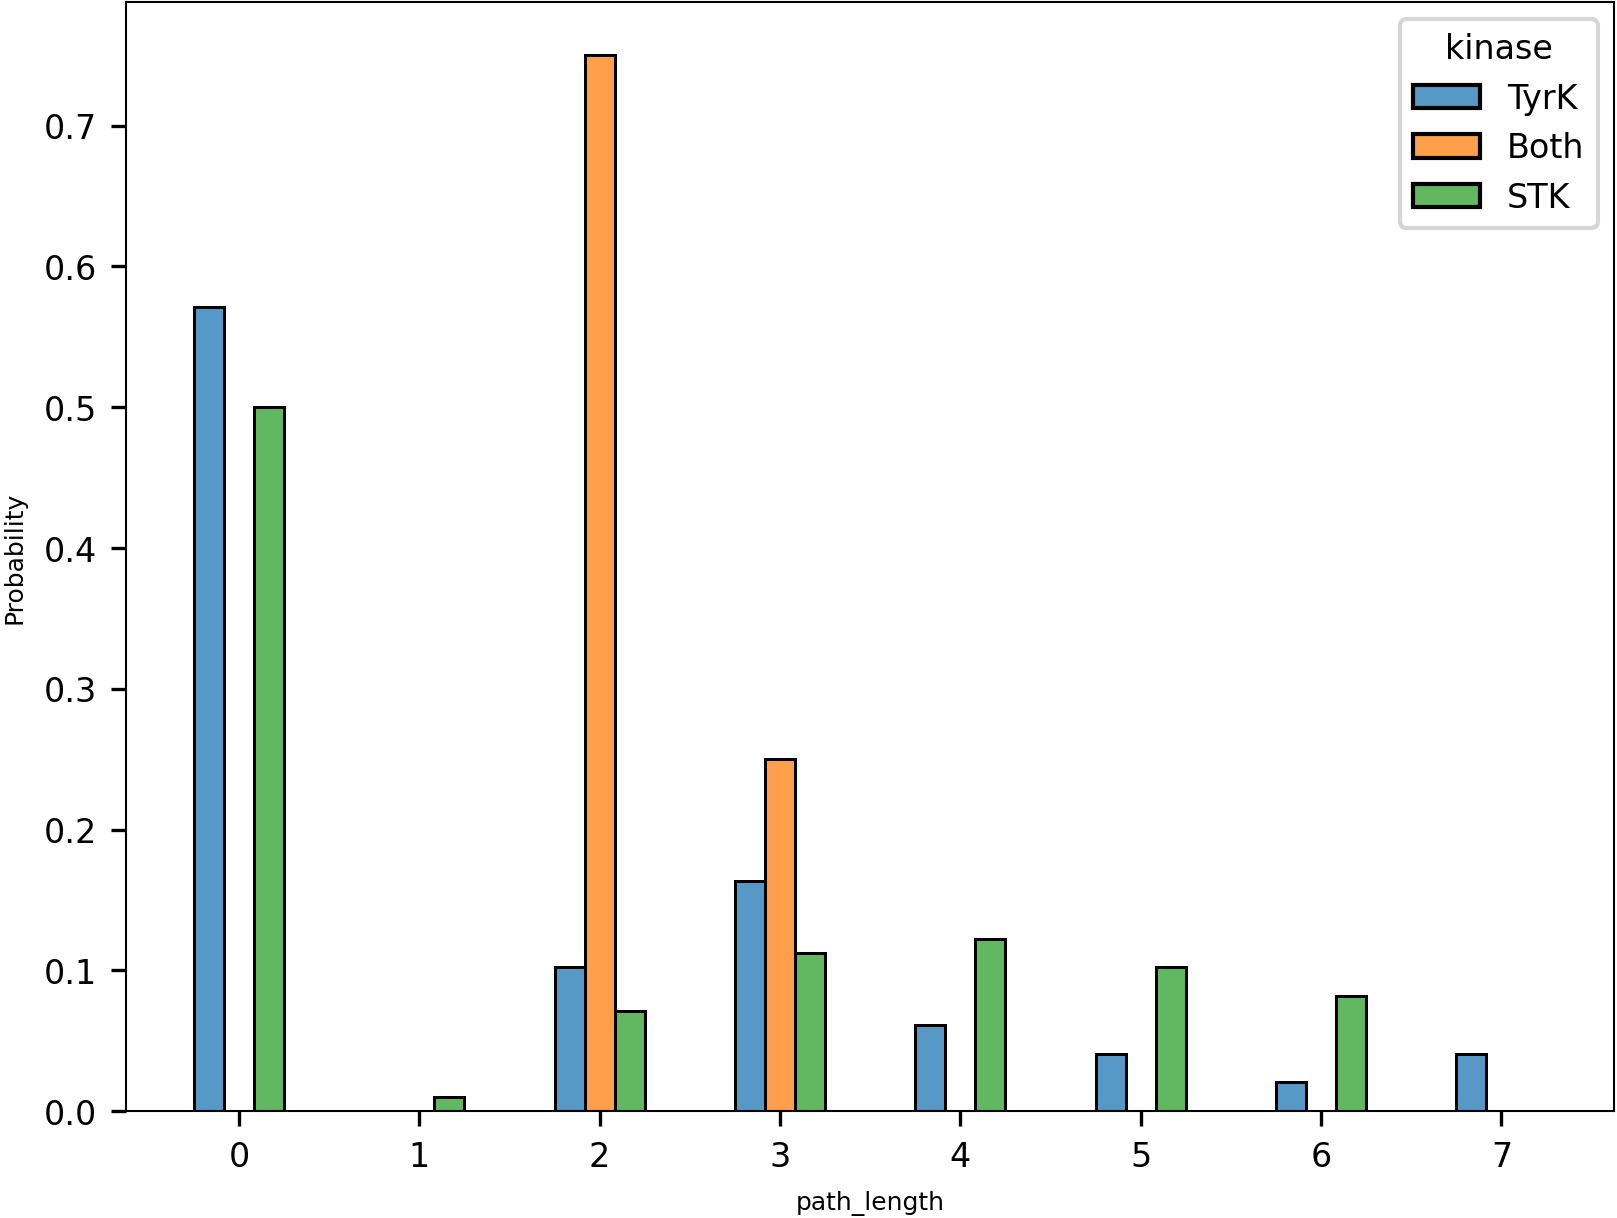

In [226]:
sns.histplot(novel_ngram_info, hue='kinase', x='path_length', multiple='dodge', bins=range(int(novel_ngram_info.path_length.max())+1),discrete=True, stat='probability',common_norm=False, shrink = 0.5)

# Diversity Index calculations
Now let's look at how diverse the kinase domains for both systems are and then relate that to their propensity to make new n-grams in fusions.

In [115]:
# Creating a function to get the diversity index of a specific domain towards either the N-terminal or C-terminal
def get_diversity_index(domain, ngram_list, terminal='N'):
    
    terminal = terminal.lower()
    
    # Now getting the instances
    ngram_counts_OI = Counter(dansy.ngramUtilities.return_ngrams_from_list(ngram_list,2)) #Only extracting 2-grams for these
    if terminal == 'n':
        fin_dom_counts = {k:v for k,v in ngram_counts_OI.items() if (k.split('|')[-1] == domain) and (len(k.split('|')) == 2)} #Just as a safety check
    elif terminal == 'c':
        fin_dom_counts = {k:v for k,v in ngram_counts_OI.items() if (k.split('|')[0] == domain) and (len(k.split('|')) == 2)} #Just as a safety check
    else:
        raise ValueError('An invalid terminal was provided')

    # Creating the dataframe to hold all the information for quick calculations
    fin_diversity_info = pd.DataFrame.from_dict(fin_dom_counts, orient='index', columns = ['n'])
    fin_diversity_info['nn-1'] = fin_diversity_info.n.apply(lambda x: x*(x-1))
    N = fin_diversity_info.n.sum()
    dom_diversity = 1-fin_diversity_info['nn-1'].sum()/(N*(N-1))

    return dom_diversity

def get_domain_ngram_list_with_NC(domain, ref, colname = 'Interpro Domain Architecture IDs'):

    ref_OI = ref[ref[colname].apply(lambda x: domain in x)].copy()
    ngram_list = ref_OI[colname].apply(lambda x: 'N-term|'+x+'|C-term')
    return ngram_list.values

def get_domain_richness(domain, ngram_list, terminal = 'N'):
    
    terminal = terminal.lower()

    ngram_OI = dansy.ngramUtilities.return_ngrams_from_list(ngram_list,2) #Only extracting 2-grams for these
    if terminal == 'n':
        fin_dom_counts = [k for k in ngram_OI if (k.split('|')[-1] == domain) and (len(k.split('|')) == 2)] #Just as a safety check
    elif terminal == 'c':
        fin_dom_counts = [k for k in ngram_OI if (k.split('|')[0] == domain) and (len(k.split('|')) == 2)] #Just as a safety check
    else:
        raise ValueError('An invalid terminal was provided')
    
    return len(fin_dom_counts)

def get_domain_bigram_terminals(domain, ngram_list, terminal = 'N'):
    
    terminal = terminal.lower()

    ngram_OI = dansy.ngramUtilities.return_ngrams_from_list(ngram_list,2) #Only extracting 2-grams for these
    if terminal == 'n':
        fin_dom_counts = [k for k in ngram_OI if (k.split('|')[-1] == domain) and (len(k.split('|')) == 2)] #Just as a safety check
    elif terminal == 'c':
        fin_dom_counts = [k for k in ngram_OI if (k.split('|')[0] == domain) and (len(k.split('|')) == 2)] #Just as a safety check

    return fin_dom_counts

In [116]:
# Get the instance counts for each of the domain n-grams

# First as part of finding the diversity also need to add tokens for the N- and C- terminal ends of the domain architectures
kinase_corpus_list = get_domain_ngram_list_with_NC('IPR000719',kinase_net.ref)
kinase_D_N = get_diversity_index('IPR000719', kinase_corpus_list,'N')
kinase_D_C = get_diversity_index('IPR000719', kinase_corpus_list,'C')
kinase_R_N = get_domain_richness('IPR000719', kinase_corpus_list,'N')
kinase_R_C = get_domain_richness('IPR000719', kinase_corpus_list,'C')
print(f'Diversity index for all STK and TK kinase domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')
print(f'Richness for all STK and TK kinase domains towards the N-terminal: {kinase_R_N} and the C-terminal: {kinase_R_C}')

Diversity index for all STK and TK kinase domains towards the N-terminal: 0.6405778459407312 and the C-terminal: 0.5490278533616979
Richness for all STK and TK kinase domains towards the N-terminal: 61 and the C-terminal: 49


In [117]:
serthr_kins['Interpro Domain Architecture IDs'].apply(lambda x: x == 'IPR000719').sum()

198

In [118]:
# Now let's repeat that but with only the TKs followed by STKs
kinase_corpus_list = get_domain_ngram_list_with_NC('IPR000719',tyr_kins)
kinase_D_N = get_diversity_index('IPR000719', kinase_corpus_list,'N')
kinase_D_C = get_diversity_index('IPR000719', kinase_corpus_list,'C')
kinase_R_N = get_domain_richness('IPR000719', kinase_corpus_list,'N')
kinase_R_C = get_domain_richness('IPR000719', kinase_corpus_list,'C')
print(f'Diversity index for TK kinase domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')
print(f'Richness for TK kinase domains towards the N-terminal: {kinase_R_N} and the C-terminal: {kinase_R_C}')
# Now STKs
kinase_corpus_list = get_domain_ngram_list_with_NC('IPR000719',serthr_kins)
kinase_D_N = get_diversity_index('IPR000719', kinase_corpus_list,'N')
kinase_D_C = get_diversity_index('IPR000719', kinase_corpus_list,'C')
kinase_R_N = get_domain_richness('IPR000719', kinase_corpus_list,'N')
kinase_R_C = get_domain_richness('IPR000719', kinase_corpus_list,'C')
print(f'Diversity index for all STK domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')
print(f'Richness for all STK domains towards the N-terminal: {kinase_R_N} and the C-terminal: {kinase_R_C}')

Diversity index for TK kinase domains towards the N-terminal: 0.8498383779018512 and the C-terminal: 0.4401998236849839
Richness for TK kinase domains towards the N-terminal: 19 and the C-terminal: 6
Diversity index for all STK domains towards the N-terminal: 0.4863687614978339 and the C-terminal: 0.5626609696753901
Richness for all STK domains towards the N-terminal: 46 and the C-terminal: 46


Now how diverse are the fusions that retain the kinase domain?

In [119]:
stk_fusions = tcga_kins_only[tcga_kins_only.stk & tcga_kins_only.domain_architecture.apply(lambda x:'IPR000719' in x)].copy()

# Now for the few where there are both an STK and a TK double check where the kinase domain is coming from
stk_fusions['stk_kinase_dom'] = stk_fusions.apply(lambda x: ((x['h_uniprot'] in serthr_kins['UniProt ID'].values) & ('IPR000719' in x['h_contribution'])) | ((x['t_uniprot'] in serthr_kins['UniProt ID'].values) & ('IPR000719' in x['t_contribution'])) , axis = 1)
stk_fusions = stk_fusions[stk_fusions.stk_kinase_dom].filter(['name', 'domain_architecture']).drop_duplicates()
kin_fusion_archs = get_domain_ngram_list_with_NC('IPR000719',stk_fusions, 'domain_architecture')
kinase_D_N = get_diversity_index('IPR000719', kin_fusion_archs,'N')
kinase_D_C = get_diversity_index('IPR000719', kin_fusion_archs,'C')
print(f'Diversity index STK kinase domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')

Diversity index STK kinase domains towards the N-terminal: 0.6183388704318937 and the C-terminal: 0.5899888517279821


In [120]:
tk_fusions = tcga_kins_only[tcga_kins_only.tk & tcga_kins_only.domain_architecture.apply(lambda x:'IPR000719' in x)].copy()

# Now for the few where there are both an STK and a TK double check where the kinase domain is coming from
tk_fusions['tk_kinase_dom'] = tk_fusions.apply(lambda x: ((x['h_uniprot'] in tyr_kins['UniProt ID'].values) & ('IPR000719' in x['h_contribution'])) | ((x['t_uniprot'] in tyr_kins['UniProt ID'].values) & ('IPR000719' in x['t_contribution'])) , axis = 1)
tk_fusions = tk_fusions[tk_fusions.tk_kinase_dom].filter(['name', 'domain_architecture']).drop_duplicates()

kin_fusion_archs = get_domain_ngram_list_with_NC('IPR000719',tk_fusions, 'domain_architecture')
kinase_D_N = get_diversity_index('IPR000719', kin_fusion_archs,'N')
kinase_D_C = get_diversity_index('IPR000719', kin_fusion_archs,'C')
print(f'Diversity index TK kinase domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')

Diversity index TK kinase domains towards the N-terminal: 0.9128145865434001 and the C-terminal: 0.38636363636363635


## Comparing the STK and TyrK fusions and where novel domain architectures are adding domain partners.

In [121]:
import itertools

In [122]:
# Focus only on the novel domain architectures for now and grab the head/tail contributions to quantify the number of relative to the kinase type
fusion_kin_contrib_counts = {kin:{s:[] for s in ['N','C']} for kin in ['TyrK','STK', 'Both'] }

for _,row in novel_info.iterrows():
    contrib,side = (row['h_contribution'],'N') if 'IPR000719' in row['t_contribution'] else (row['t_contribution'],'C')
    kin = get_kinase_type(row)
    fusion_kin_contrib_counts[kin][side].append(contrib)


In [123]:
fusion_kin_contrib_counts_df = pd.DataFrame(
    {
        kinase: {side: len(values) for side, values in sides.items()}
        for kinase, sides in fusion_kin_contrib_counts.items()
    }
).T

fusion_kin_contrib_counts_df.reset_index(inplace=True, names='Kinase')
kin_fusions_terminal_dists = fusion_kin_contrib_counts_df.melt(id_vars = 'Kinase', var_name='Terminal')

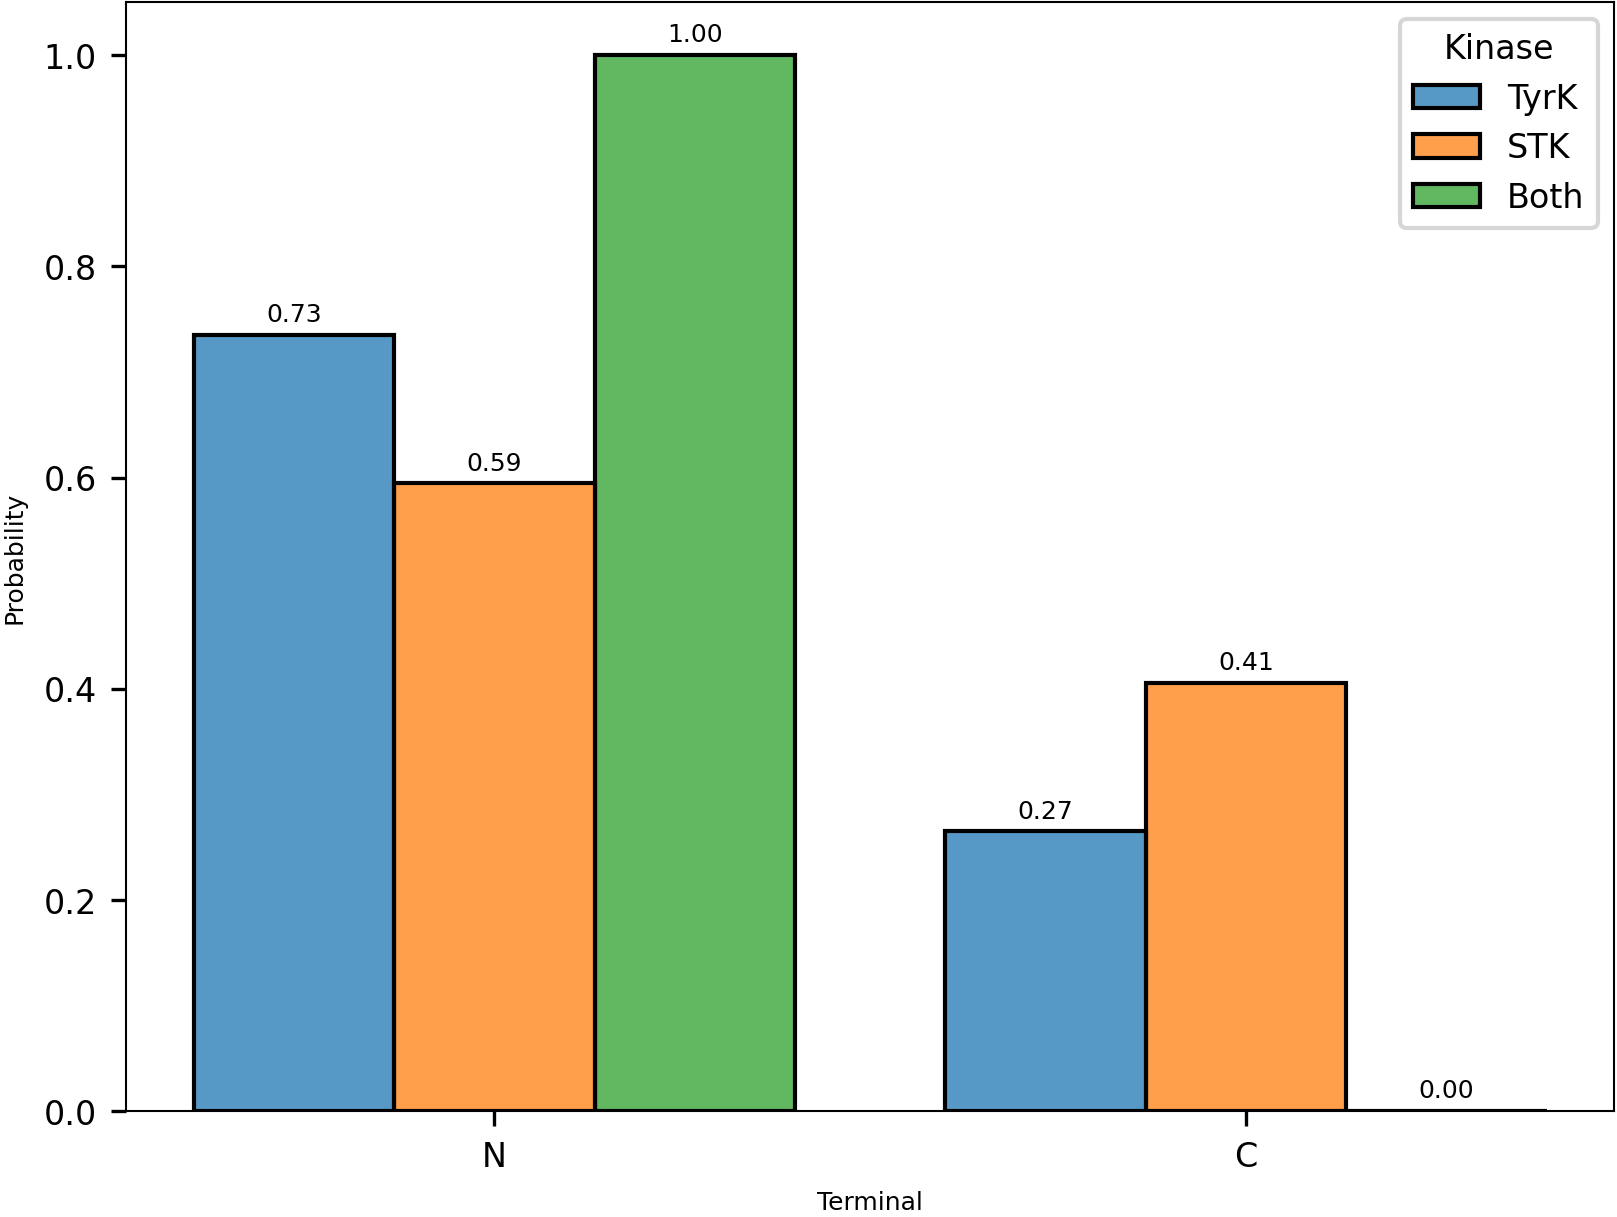

In [124]:
ax = sns.histplot(kin_fusions_terminal_dists, 
            hue = 'Kinase', weights = 'value', 
            x='Terminal',
            multiple='dodge',
            shrink= 0.8,
            stat='probability', common_norm=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=6, color='black')

In [125]:
# Find out how many of these are new sequential domain additions or not.
novel_kin_bigrams = pd.DataFrame(index = ['TyrK','STK'], columns = ['N','C'], dtype=int)

kinase_corpus_list = get_domain_ngram_list_with_NC('IPR000719',kinase_net.ref)

for kinase_type in novel_kin_bigrams.index:
    kinase_subset = novel_info[
        novel_info.apply(get_kinase_type, axis=1).eq(kinase_type)
    ]
    
    for terminal in novel_kin_bigrams.columns:

        novel_kin_bigrams.loc[kinase_type, terminal] = len(set(get_domain_bigram_terminals('IPR000719', kinase_subset.domain_architecture,terminal)).difference(get_domain_bigram_terminals('IPR000719',kinase_corpus_list,terminal))
        )

novel_kin_bigrams.reset_index(names = 'Kinase', inplace=True)
novel_kin_bigrams = novel_kin_bigrams.melt(id_vars = 'Kinase', var_name='Terminal')

In [126]:
novel_kin_bigrams

,Kinase,Terminal,value
0,TyrK,N,16.0
1,STK,N,34.0
2,TyrK,C,9.0
3,STK,C,31.0


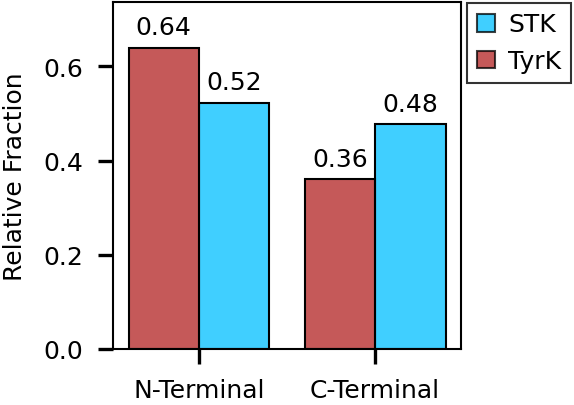

In [169]:
f,ax = plt.subplots(figsize = (1.5,1.5),dpi=300)
sns.histplot(novel_kin_bigrams, hue = 'Kinase', weights = 'value', 
            x='Terminal',
            multiple='dodge',
            shrink= 0.8,
            stat='probability', 
            common_norm=False,
            palette=col_map,
            linewidth = 0.5,
            ax = ax)
ax.tick_params(labelsize=6)
ax.margins(y = 0.15)
ax.legend(handles[0:2], 
          labels[0:2],
          handlelength = 0.75, 
          handletextpad = 0.5,
          bbox_to_anchor=(1.35,1.035),
          fancybox = False, edgecolor = 'k', fontsize = 6).get_frame().set_linewidth(0.5)
ax.set_ylabel('Relative Fraction')
ax.set_xticks([0,1])
ax.set_xticklabels(['N-Terminal', 'C-Terminal'])
ax.set_xlabel(None)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=6, color='black')

plt.savefig('Figures/Manuscript/Figure_4/Kinase_Domain_Partners_Terminal.svg')

Let me check really quick if the kinase domain is frequently being donated by itself or not in the different kinase fusions.

In [368]:
kin_donation = {}
for kinase_type in ['TyrK','STK']:
    kinase_subset = novel_info[
        novel_info.apply(get_kinase_type, axis=1).eq(kinase_type)
    ]
    cons = []
    for _,row in kinase_subset.iterrows():
        c = row['t_contribution'] if "IPR000719" in row['t_contribution'] else row['h_contribution']
        cons.append(c)

    kin_donation[kinase_type] = Counter(cons)
    


# Now let's check overall the Enrichment results and compare to the diversity indices.

In [141]:
full_proteome = dansy.dansy(ref = ref_df, n = 15)

Starting to fetch n-grams.
Finished getting all n-grams
Collapsing n-grams
Finished creating edgelist


In [142]:
# Importing enrichment results
tcga_dom_enrichment = pd.read_csv('TCGA_Fusion_Domain_Enrichment_Results.csv', index_col = 0)
tcga_dom_enrichment.dropna(subset = 'ngram', inplace=True)
tcga_null_res = pd.read_csv('Null_p_val_dists_15K_tcga.csv',index_col=0)

In [143]:
# Getting only single domains since most of the significantlt enriched n-grams are single domains and not multi-domains
tcga_single_dom = tcga_dom_enrichment[tcga_dom_enrichment['ngram'].apply(lambda x: len(x.split('|')) == 1)].copy()
tcga_single_dom.set_index('ngram',inplace=True)
div_res = []
for ngram in tcga_single_dom.index:
    nlist = get_domain_ngram_list_with_NC(ngram, ref_df)
    if len(nlist) > 1:
        DN = get_diversity_index(ngram, nlist,'N')
        DC = get_diversity_index(ngram, nlist,'C')
    else:
        DN = 0
        DC = 0
    div_res.append((ngram, DN, DC))

In [144]:
# Do a quick FPR check for each domain
fpr_res =[]
for ngram in tcga_single_dom.index:
    if ngram in tcga_null_res.index:
        fpr = tcga_null_res.loc[ngram].le(tcga_single_dom.loc[ngram,'True_q']).sum()/100
    elif tcga_single_dom.loc[ngram,'True_q'] > 0.001:
        fpr = 1
    else:
        fpr = 0
    
    fpr_res.append((ngram,fpr))

In [145]:
div_res_df = pd.DataFrame.from_records(div_res, columns = ['ngram', 'N_term_D', 'C_term_D']).set_index('ngram')
fpr_res_df = pd.DataFrame.from_records(fpr_res, columns = ['ngram','FPR']).set_index('ngram')


In [146]:
dataOI = tcga_single_dom.merge(div_res_df, left_index=True, right_index=True).merge(fpr_res_df, left_index= True, right_index=True)
dataOI['True_q_log'] = dataOI.True_q.apply(lambda x: -1*np.log10(x))
dataOI['fpr_good'] = dataOI.FPR <= 0.05
dataOI['domain_name'] = [full_proteome.return_legible_ngram(i) for i in dataOI.index]

In [183]:
dataOI

,False,True,n,False_q,True_q,fpr,fpr_sig,N_term_D,C_term_D,FPR,True_q_log,fpr_good,domain_name
ngram,,,,,,,,,,,,,
IPR000001,0.996393,2.427259e-02,9.0,1.0,1.318785e-01,0.26,False,0.823333,0.770000,0.26,0.879826,False,Kringle
IPR000007,0.746705,1.000000e+00,2.0,1.0,1.000000e+00,0.89,False,0.700000,0.000000,0.89,-0.000000,False,Tubby_C
IPR000008,1.000000,1.784068e-15,173.0,1.0,7.681901e-13,0.05,True,0.790796,0.816362,0.05,12.114531,True,C2_dom
IPR000014,0.999871,6.673860e-04,24.0,1.0,1.532445e-02,0.29,False,0.751089,0.834543,0.29,1.814615,False,PAS
IPR000020,0.949648,3.547665e-01,3.0,1.0,5.614329e-01,0.58,False,0.750000,0.714286,0.58,0.250702,False,Anaphylatoxin/fibulin
...,...,...,...,...,...,...,...,...,...,...,...,...,...
IPR059182,0.979769,1.393500e-01,5.0,1.0,3.923823e-01,0.16,False,0.000000,0.000000,0.16,0.406291,False,Khc_C
IPR059828,0.999715,1.451436e-03,22.0,1.0,2.627661e-02,0.00,True,0.000000,0.000000,0.00,1.580431,True,VMP1_C
IPR059983,0.809178,5.837123e-01,6.0,1.0,8.021387e-01,0.25,False,0.000000,0.000000,0.25,0.095751,False,PRR11_1st


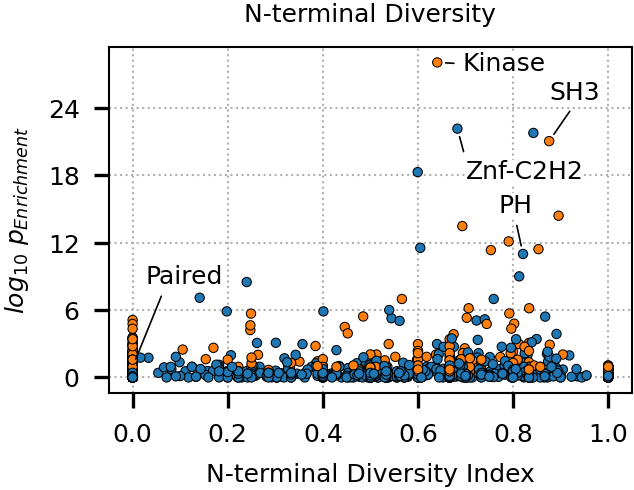

In [ ]:
ax = sns.scatterplot(dataOI, x='N_term_D', y = 'True_q_log', 
                     hue = 'fpr_good', s=5, legend = False,
                     linewidth = 0.25, edgecolor = 'k', zorder=2)
plt.xlabel('N-terminal Diversity Index', fontdict={'fontsize':6})
plt.ylabel(r'$log_{10}$ $p_{Enrichment}$', fontdict={'fontsize':6})
plt.gcf().set_size_inches(2.25,1.5)
plt.gcf().set_dpi(300)
plt.title('N-terminal Diversity', fontdict={'fontsize':6})
plt.grid(lw=0.5, ls=':', zorder=0)
ax.yaxis.set_major_locator(MaxNLocator(6))
plt.tick_params(labelsize = 6)

# Adding annotations for a couple of key domains
for ngram, offset, relpos,label in zip(['IPR000719','IPR001452','IPR001849','IPR013087'],[(6, -2),(0, 10),(-6,10),(2,-12)],[(0,0.5),(0.5,0),(0.5,0),(0,1)],['Kinase','SH3','PH','Znf-C2H2']):
    point = dataOI.loc[ngram]
    if not point.empty:
        x, y = point[['N_term_D','True_q_log']]
        ax.annotate(
            label,
            (x, y),
            xytext=offset,
            textcoords='offset points',
            fontsize=6,
            arrowprops={'arrowstyle': '-', 'lw': 0.4, 'color': 'k','relpos':relpos},
            bbox = dict(pad=0, facecolor='w', lw=0)
        )

plt.savefig('Figures/Manuscript/Figure_4/4Ei_N-terminal_Diversity.svg')

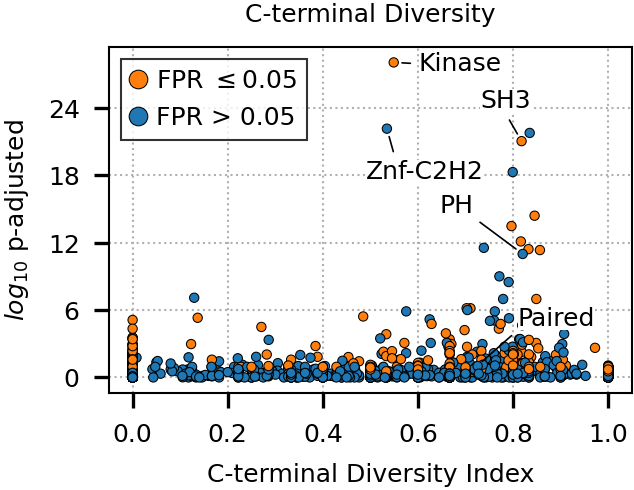

In [ ]:
ax = sns.scatterplot(dataOI, x='C_term_D', y = 'True_q_log', hue = 'fpr_good', s = 5,
                     linewidth = 0.25, edgecolor = 'k', zorder=2)
plt.xlabel('C-terminal Diversity Index', fontdict={'fontsize':6})
plt.ylabel(r'$log_{10}$ p-adjusted', fontdict={'fontsize':6})
plt.gcf().set_size_inches(2.25,1.5)
plt.gcf().set_dpi(300)
plt.title('C-terminal Diversity', fontdict={'fontsize':6})
plt.tick_params(labelsize = 6)
handles,_ = ax.get_legend_handles_labels()
ax.yaxis.set_major_locator(MaxNLocator(6))
plt.grid(lw=0.5, ls=':', zorder=0)
plt.legend(handles = handles[::-1], 
           labels = [r'FPR $\leq$0.05', 'FPR > 0.05'],
           loc = 'upper left', 
           title = None, 
           handletextpad = 0.5,markerscale = 2,handlelength = 0.5,
           fontsize = 6, edgecolor = 'k', fancybox = False).get_frame().set_linewidth(0.5)

for ngram, offset, relpos,label in zip(['IPR000719','IPR001452','IPR001849','IPR013087'],[(6, -2),(-10, 8),(-20,10),(-5,-12)],[(0,0.5),(0.5,0),(1,0),(0.25,1)],['Kinase','SH3','PH','Znf-C2H2']):
    point = dataOI.loc[ngram]
    if not point.empty:
        x, y = point[['C_term_D','True_q_log']]
        ax.annotate(
            label,
            (x, y),
            xytext=offset,
            textcoords='offset points',
            fontsize=6,
            arrowprops={'arrowstyle': '-', 'lw': 0.4, 'color': 'k','relpos':relpos},
            bbox = dict(pad=0, facecolor='w', lw=0)
        )

plt.savefig('Figures/Manuscript/Figure_4/4Eii_C-terminal_Diversity.svg')